# Fire Department Calls for Service Analysis (San Francisco Dataset)

## Problem Statement  

The San Francisco Fire Department (SFFD) responds to thousands of emergency calls every year, ranging from medical incidents and structure fires to alarms and other critical events. Analyzing these calls is essential for understanding public safety patterns, identifying high-demand neighborhoods, optimizing resource allocation, and improving emergency response efficiency.  

This project explores the San Francisco Fire Department Calls for Service dataset to extract key insights and uncover meaningful trends.  

### Key Questions Explored in the Analysis  

- 1) What are the most common types of emergency calls in San Francisco? 
- 2) Which neighborhoods have the highest number of emergency calls?  
- 3) On which day of the week do most emergency calls occur?  
- 4) At what time of day are emergency calls most frequent?  
- 5) How have emergency calls changed over the years?


---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("default")
sns.set_theme(style="whitegrid")


In [3]:
df = pd.read_csv("fire_Dept.csv")  
df.head()

C:\Users\MUKIL\AppData\Local\Temp\ipykernel_14100\2797144812.py:1: DtypeWarning: Columns (12,13,18) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("fire_Dept.csv")


,CallNumber,UnitID,IncidentNumber,CallType,CallDate,WatchDate,CallFinalDisposition,AvailableDtTm,Address,City,...,CallTypeGroup,NumAlarms,UnitType,UnitSequenceInCallDispatch,FirePreventionDistrict,SupervisorDistrict,Neighborhood,Location,RowID,Delay
0,20110014,M29,2003234,Medical Incident,2002-01-11,2002-01-10,Other,NaN,10TH ST/MARKET ST,SF,...,NaN,1,MEDIC,1.0,2.0,6.0,Tenderloin,"(37.7765408927183, -122.417501464907)",020110014-M29,5.23
1,20110015,M08,2003233,Medical Incident,2002-01-11,2002-01-10,Other,NaN,300 Block of 5TH ST,SF,...,NaN,1,MEDIC,1.0,3.0,6.0,South of Market,"(37.7792841462441, -122.402061300134)",020110015-M08,3.08
2,20110016,B02,2003235,Structure Fire,2002-01-11,2002-01-10,Other,NaN,2000 Block of CALIFORNIA ST,SF,...,NaN,1,CHIEF,6.0,4.0,5.0,Pacific Heights,"(37.7895840679362, -122.428071912459)",020110016-B02,3.05
3,20110016,B04,2003235,Structure Fire,2002-01-11,2002-01-10,Other,NaN,2000 Block of CALIFORNIA ST,SF,...,NaN,1,CHIEF,3.0,4.0,5.0,Pacific Heights,"(37.7895840679362, -122.428071912459)",020110016-B04,2.32
4,20110016,D2,2003235,Structure Fire,2002-01-11,2002-01-10,Other,NaN,2000 Block of CALIFORNIA ST,SF,...,NaN,1,CHIEF,4.0,4.0,5.0,Pacific Heights,"(37.7895840679362, -122.428071912459)",020110016-D2,3.02


# Basic details of the dataset

In [10]:
print("Shape of dataset:", df.shape)
print("\nColumn names:\n", df.columns)
print("\nData types:\n")
df.info()

Shape of dataset: (4380660, 28)

Column names:
 Index(['CallNumber', 'UnitID', 'IncidentNumber', 'CallType', 'CallDate',
       'WatchDate', 'CallFinalDisposition', 'AvailableDtTm', 'Address', 'City',
       'ZipCodeOfIncident', 'Battalion', 'StationArea', 'Box', 'OrigPriority',
       'Priority', 'FinalPriority', 'ALSUnit', 'CallTypeGroup', 'NumAlarms',
       'UnitType', 'UnitSequenceInCallDispatch', 'FirePreventionDistrict',
       'SupervisorDistrict', 'Neighborhood', 'Location', 'RowID', 'Delay'],
      dtype='object')

Data types:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4380660 entries, 0 to 4380659
Data columns (total 28 columns):
 #   Column                      Dtype  
---  ------                      -----  
 0   CallNumber                  int64  
 1   UnitID                      object 
 2   IncidentNumber              int64  
 3   CallType                    object 
 4   CallDate                    object 
 5   WatchDate                   object 
 6   CallFinalD

# Convert relevant columns to datetime

In [28]:
df['CallDate'] = pd.to_datetime(df['CallDate'], errors='coerce')
df['AvailableDtTm'] = pd.to_datetime(df['AvailableDtTm'], errors='coerce')

df['DayOfWeek'] = df['CallDate'].dt.day_name()
df['Hour'] = df['CallDate'].dt.hour
df['Year'] = df['CallDate'].dt.year


# 1)

In [30]:
df['CallType'].value_counts()

CallType
Medical Incident                                2843475
Structure Fire                                   578998
Alarms                                           483518
Traffic Collision                                175507
Citizen Assist / Service Call                     65360
Other                                             56961
Outside Fire                                      51603
Vehicle Fire                                      20939
Water Rescue                                      20037
Gas Leak (Natural and LP Gases)                   17284
Electrical Hazard                                 12608
Elevator / Escalator Rescue                       11851
Odor (Strange / Unknown)                          11680
Smoke Investigation (Outside)                      9796
Fuel Spill                                         5198
HazMat                                             3437
Industrial Accidents                               2401
Explosion                              

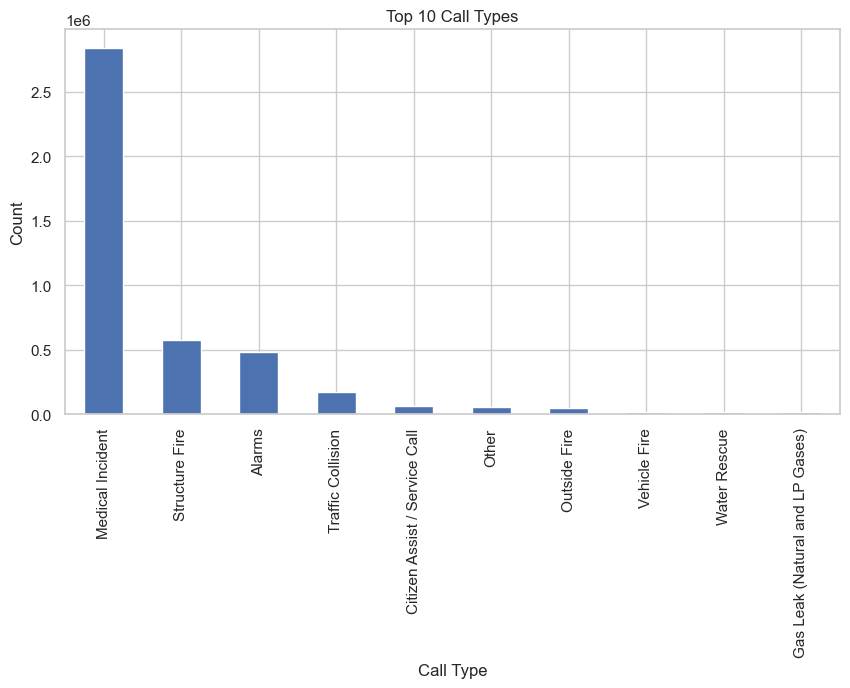

In [32]:
plt.figure(figsize=(10,5))
df['CallType'].value_counts().head(10).plot(kind='bar')
plt.title("Top 10 Call Types")
plt.xlabel("Call Type")
plt.ylabel("Count")
plt.show()

# 2)

In [34]:
df['Neighborhood'].value_counts().head(10)

Neighborhood
Tenderloin                        568007
South of Market                   414361
Mission                           396919
Financial District/South Beach    296358
Bayview Hunters Point             238980
Sunset/Parkside                   176268
Western Addition                  162686
Nob Hill                          145052
Outer Richmond                    117873
Hayes Valley                      108643
Name: count, dtype: int64

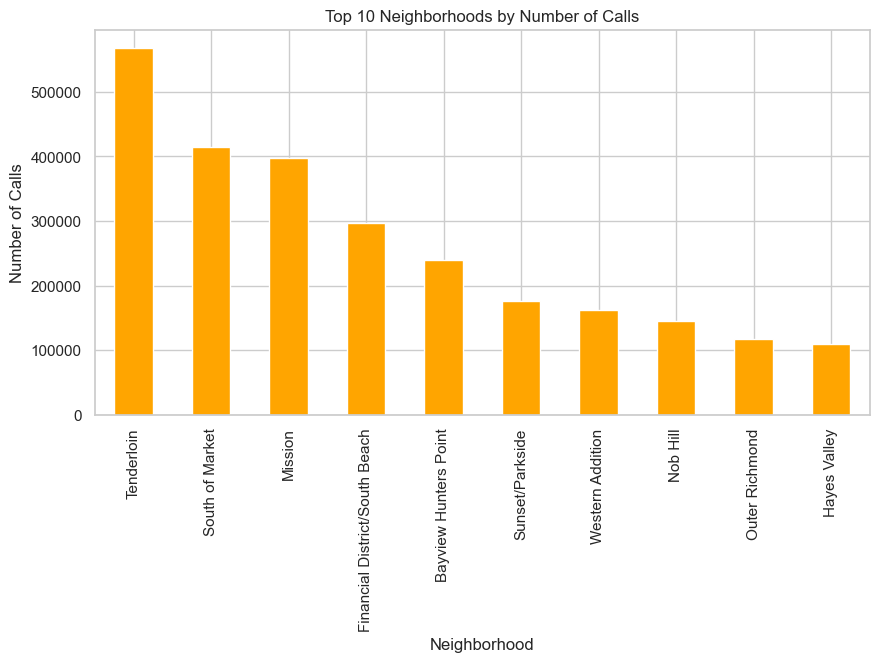

In [36]:
plt.figure(figsize=(10,5))
df['Neighborhood'].value_counts().head(10).plot(kind='bar', color='orange')
plt.title("Top 10 Neighborhoods by Number of Calls")
plt.xlabel("Neighborhood")
plt.ylabel("Number of Calls")
plt.show()

# 3)

In [39]:
df['DayOfWeek'].value_counts()

DayOfWeek
Saturday     646876
Friday       646814
Sunday       621464
Thursday     619816
Monday       619636
Wednesday    614369
Tuesday      611685
Name: count, dtype: int64

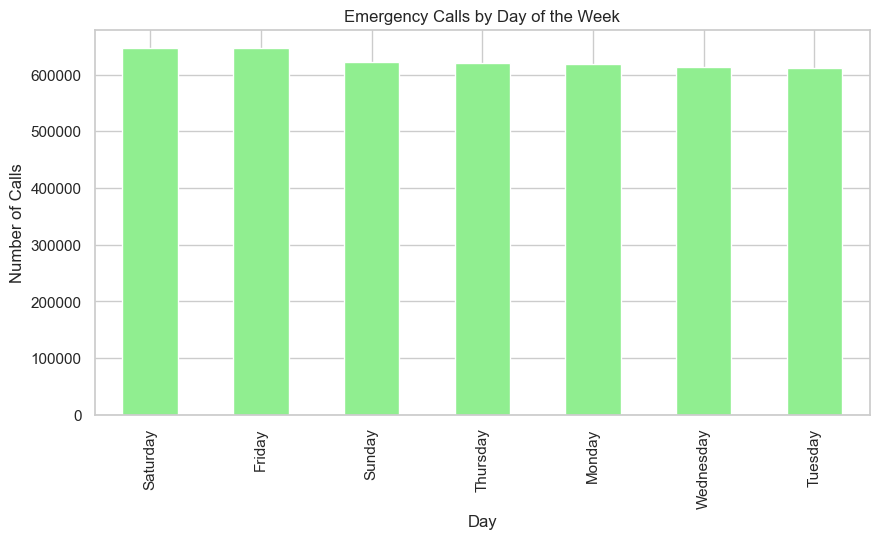

In [41]:
plt.figure(figsize=(10,5))
df['DayOfWeek'].value_counts().plot(kind='bar', color='lightgreen')
plt.title("Emergency Calls by Day of the Week")
plt.xlabel("Day")
plt.ylabel("Number of Calls")
plt.show()

# 4)

In [46]:
df['Hour'].value_counts().sort_index()

Hour
0    4380660
Name: count, dtype: int64

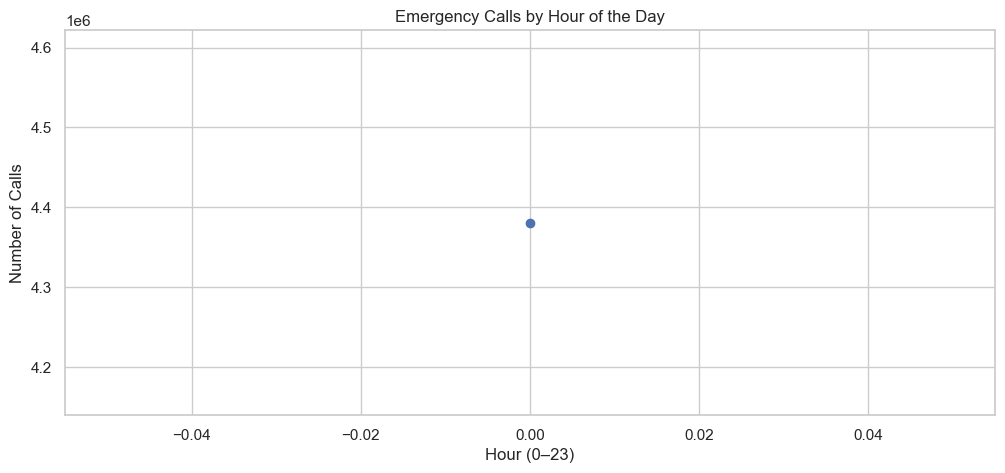

In [48]:
plt.figure(figsize=(12,5))
df['Hour'].value_counts().sort_index().plot(kind='line', marker='o')
plt.title("Emergency Calls by Hour of the Day")
plt.xlabel("Hour (0–23)")
plt.ylabel("Number of Calls")
plt.show()

# 5)

In [51]:
df['Year'].value_counts().sort_index()

Year
2000    139200
2001    194309
2002    201575
2003    214503
2004    211056
2005    204569
2006    204616
2007    208250
2008    221652
2009    217800
2010    228567
2011    242121
2012    241714
2013    248796
2014    268074
2015    285281
2016    292526
2017    301449
2018    254602
Name: count, dtype: int64

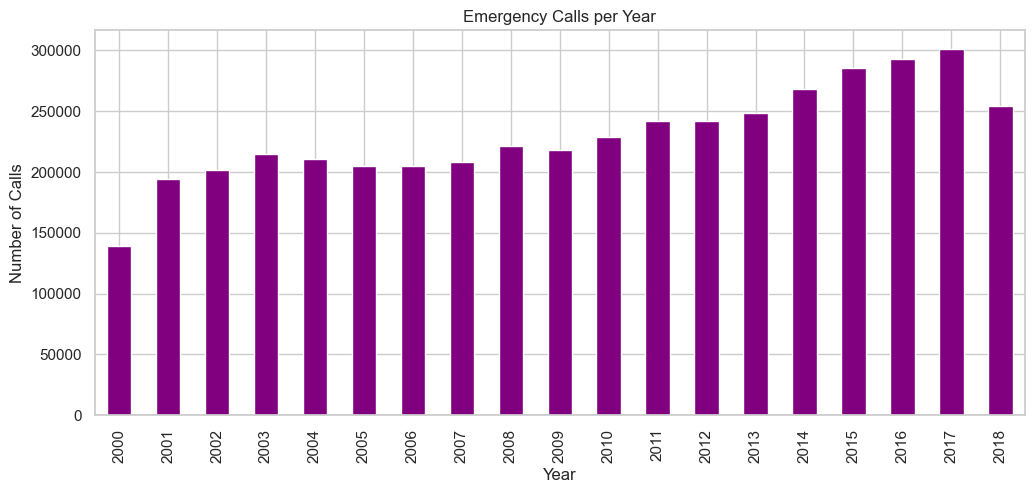

In [53]:
plt.figure(figsize=(12,5))
df['Year'].value_counts().sort_index().plot(kind='bar', color='purple')
plt.title("Emergency Calls per Year")
plt.xlabel("Year")
plt.ylabel("Number of Calls")
plt.show()